In [2]:
# Do the necessary import
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
pickle_file = "HR_analytics_data_clean.pkl"

In [3]:
# Lets verify that above works
df = pd.read_pickle(pickle_file)
print(df.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int8    
 1   Attrition                 1470 non-null   bool    
 2   BusinessTravel            1470 non-null   category
 3   DailyRate                 1470 non-null   int16   
 4   Department                1470 non-null   category
 5   DistanceFromHome          1470 non-null   int8    
 6   Education                 1470 non-null   int8    
 7   EducationField            1470 non-null   category
 8   EnvironmentSatisfaction   1470 non-null   int8    
 9   Gender                    1470 non-null   category
 10  HourlyRate                1470 non-null   int8    
 11  JobInvolvement            1470 non-null   int8    
 12  JobLevel                  1470 non-null   int8    
 13  JobRole                   1470 non-null   catego

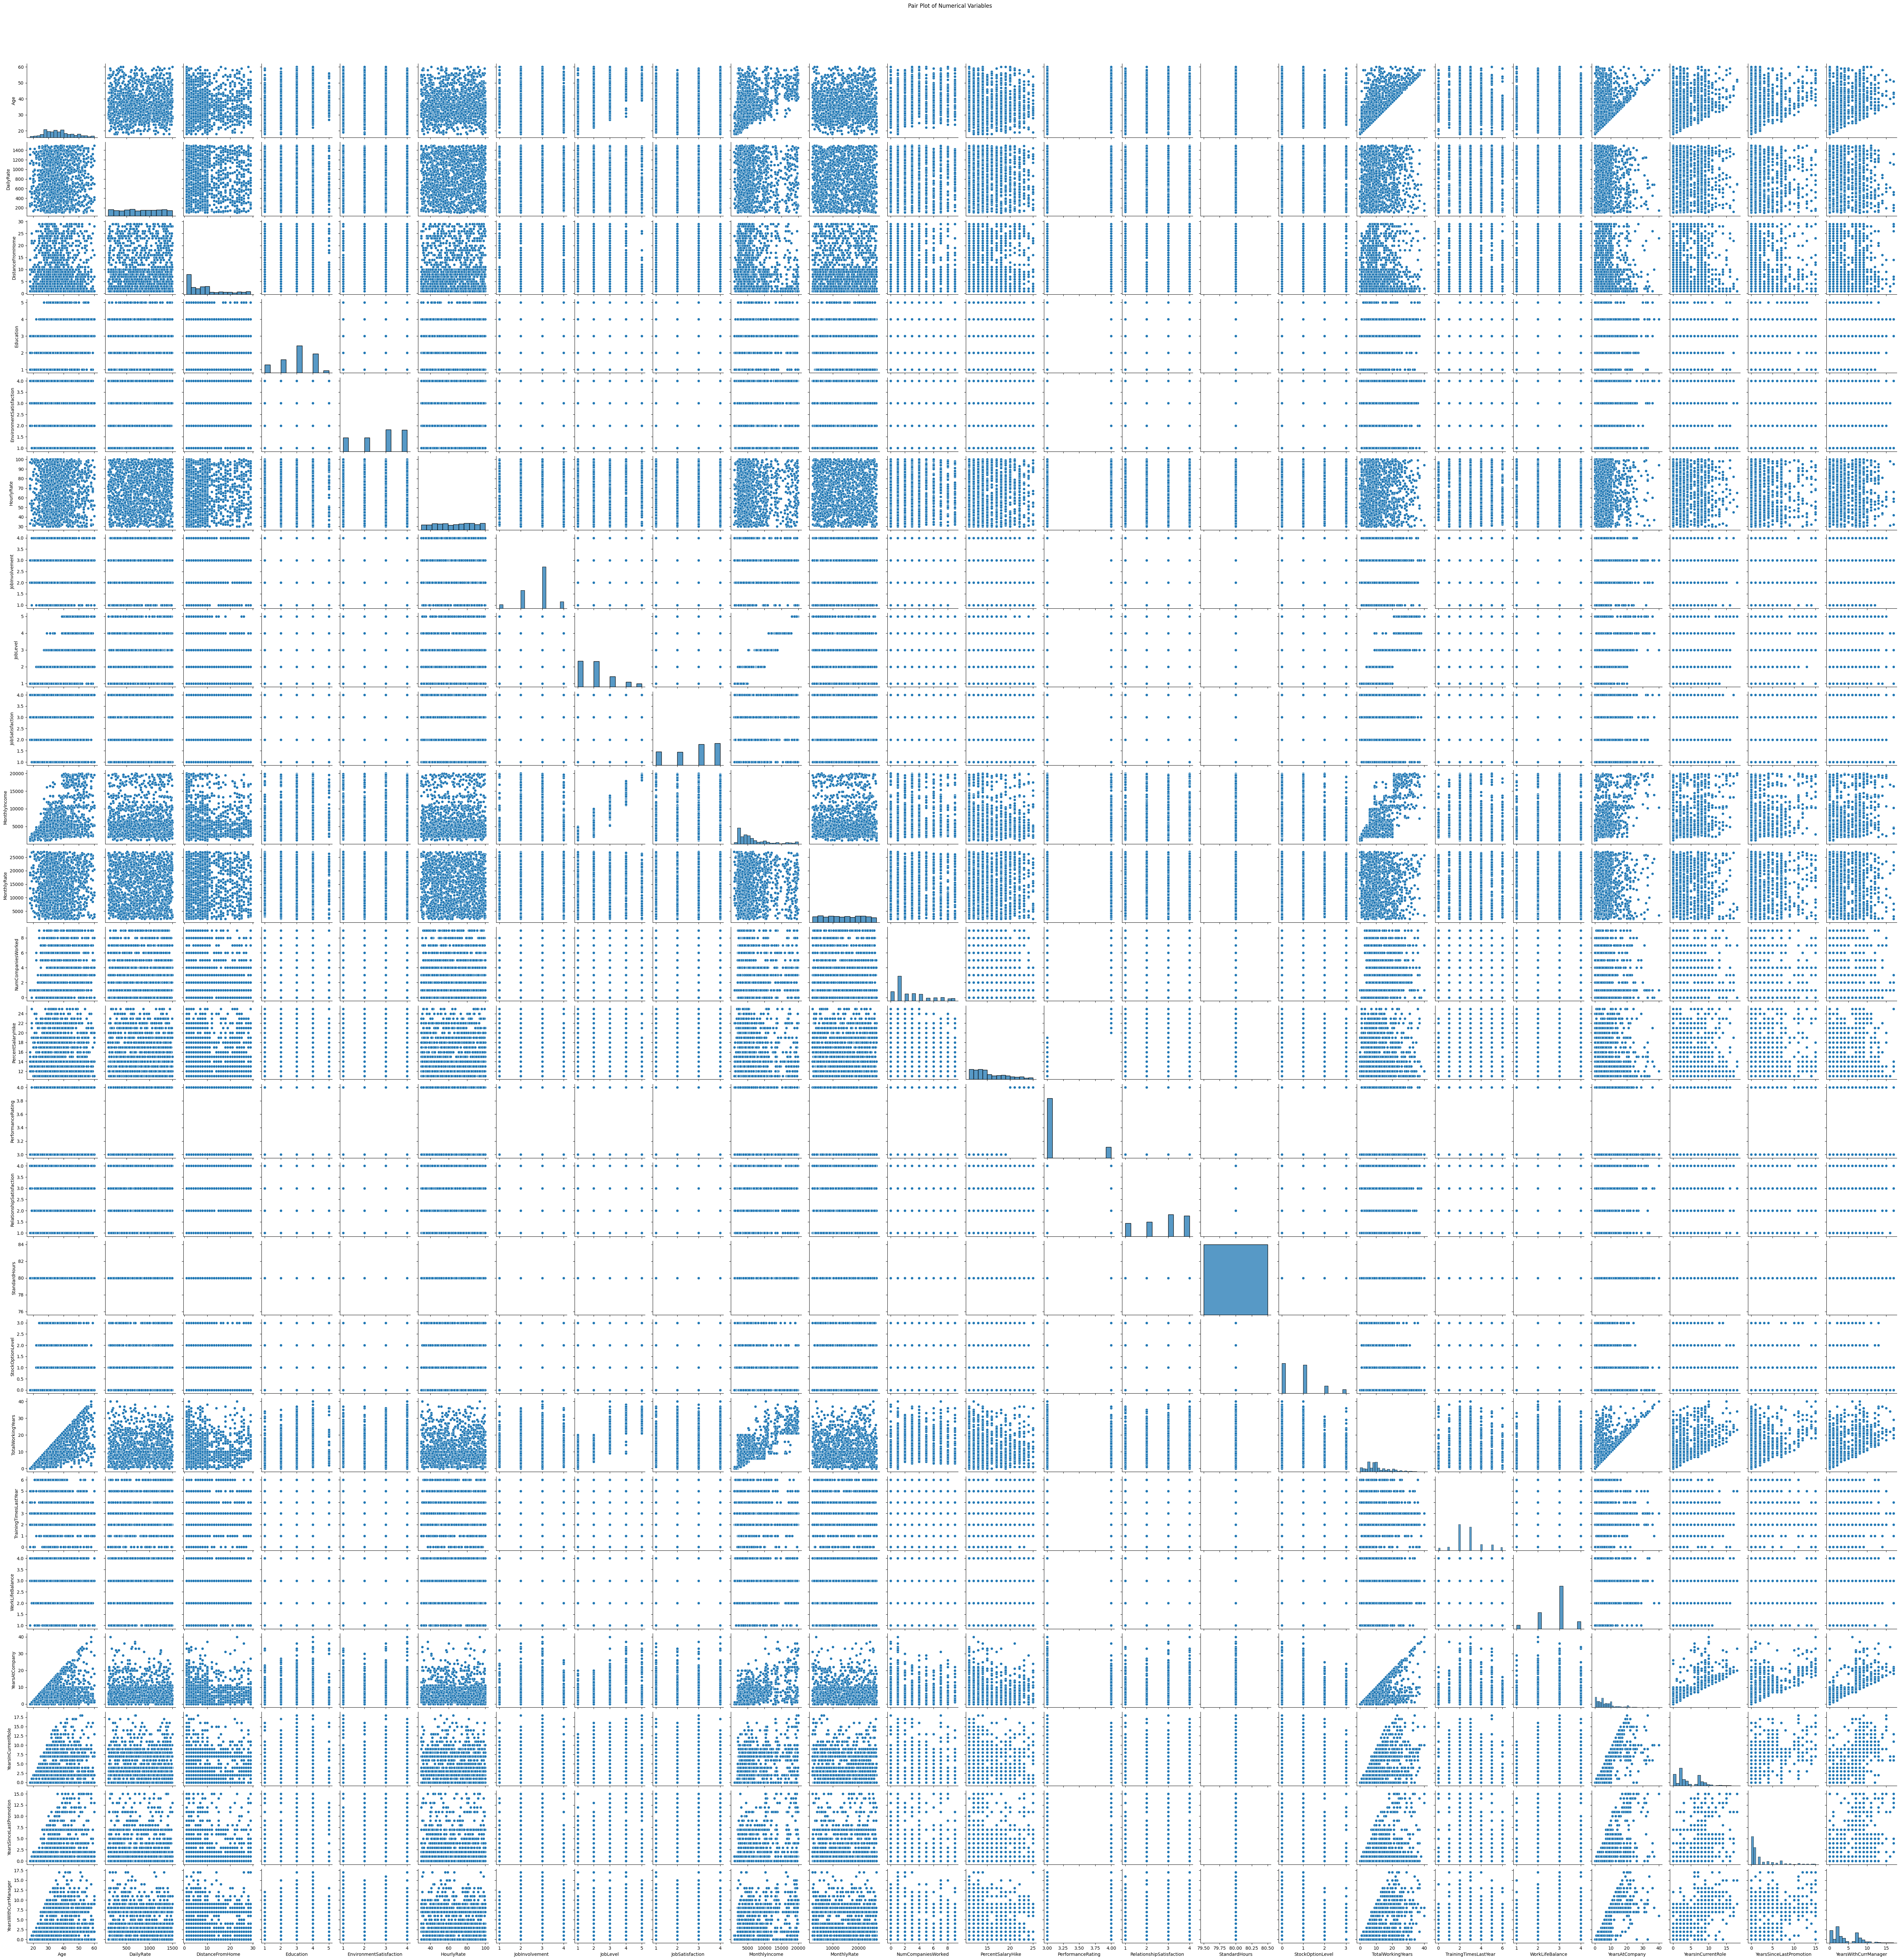

In [4]:
# NOTE: This took 5 minutes

# STEP1: Now we do pair plots: Here we would notice that there are large numbers of pairs. 
# So it is difficult to understand the plot
# Select only numeric columns automatically
numeric_df = df.select_dtypes(include=['int8', 'int16'])

# Pair plot
sns.pairplot(numeric_df)
plt.suptitle('Pair Plot of Numerical Variables', y=1.02)
plt.show()

C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\hi\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


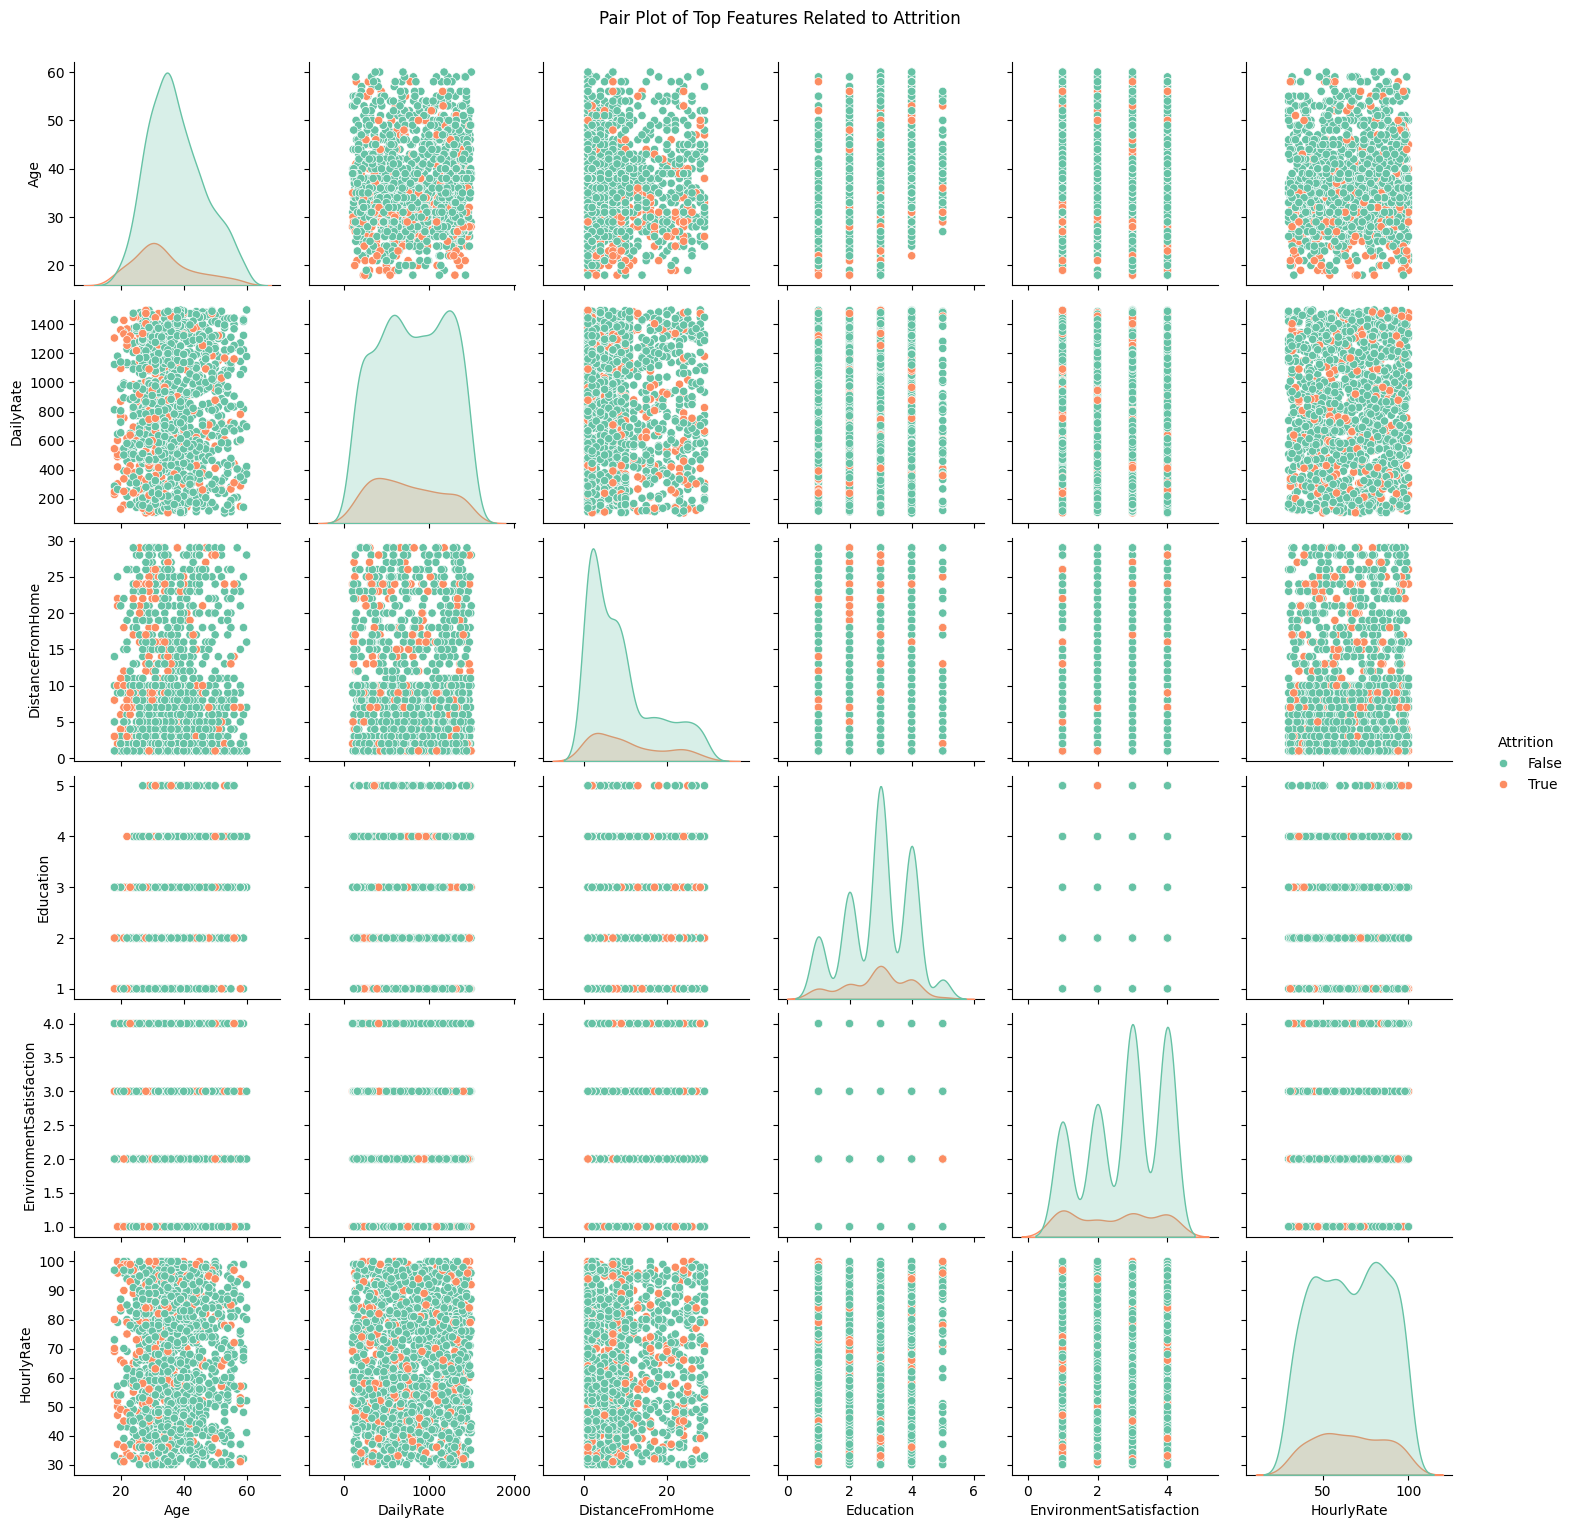

In [5]:
# step2: Problem with above: Image is too small because of large number of pairs
# Example: Select top correlated variables with Attrition
numeric_df = df.select_dtypes(include=['int8', 'int16'])

corr_with_target = numeric_df.corrwith(df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0))
top_features = corr_with_target.abs().sort_values(ascending=False).head(6).index

sns.pairplot(df, vars=top_features, hue='Attrition', palette='Set2', diag_kind='kde')
plt.suptitle('Pair Plot of Top Features Related to Attrition', y=1.02)
plt.show()


PerformanceRating     3     4
WorkLifeBalance              
1                  82.5  17.5
2                  86.0  14.0
3                  84.2  15.8
4                  85.0  15.0


+++++++++++



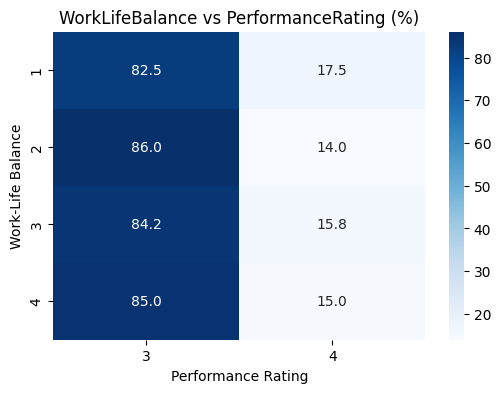

In [4]:
# 'WorkLifeBalance:  1 = Bad, 2 = Good, 3 = Better, 4 = Best
# PerformanceRating" 1 = Low, 2 = Good, 3 = Excellent, 4 = Outstanding
crosstab = pd.crosstab(df['WorkLifeBalance'], df['PerformanceRating'], normalize='index') * 100
print(crosstab.round(1))
print("\n\n+++++++++++\n")

plt.figure(figsize=(6,4))
sns.heatmap(crosstab, annot=True, cmap='Blues', fmt='.1f')
plt.title('WorkLifeBalance vs PerformanceRating (%)')
plt.xlabel('Performance Rating')
plt.ylabel('Work-Life Balance')
plt.show()

# observ: 85% of employees have given PR=3(excellent) and WLB=4(best)

In [ ]:
# Feature 